## Fruits 100 dataset preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_hub
from tensorflow.keras import mixed_precision
from tensorflow_hub import KerasLayer
import PIL.Image as Image
import pathlib
import os

c:\Users\hp\OneDrive\Desktop\FoodAdvisor\env\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [3]:
print(np.__version__)
mixed_precision.set_global_policy("mixed_float16")

2.3.3


In [2]:
print(tf.__version__)
tensorflow_hub.__version__

2.20.0


'0.16.1'

In [ ]:
# Splitting the data into train and validation datasets
# import os
# import shutil
# from sklearn.model_selection import train_test_split

# val_ratio = 0.2

# classes = os.listdir("new_data/images/")
# for class_name in classes:
#     class_dir = os.path.join("new_data/images", class_name)   
#     images = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
#     train_images, val_images = train_test_split(images, test_size=val_ratio, random_state=42)
#     val_class_dir = os.path.join("data/val", class_dir)
#     os.makedirs(val_class_dir, exist_ok=True)
    
#     for image in val_images:
#         src = os.path.join(class_dir, image)
#         dest = os.path.join(val_class_dir, image)
#         shutil.move(src, dest)




In [ ]:
dir_path = "new_data/images/"
print(len(os.listdir(dir_path)))
min_length = 1000
for dir in os.listdir(dir_path):
    print(len(os.listdir(os.path.join(dir_path, dir))))



In [4]:
print(len(os.listdir("data/train/")))
print(len(os.listdir("data/val/data/train")))

NameError: name 'os' is not defined

In [2]:
print(f"Ramen train dataset lenght: {len(os.listdir("data/train/ravioli"))}")
print(f"Ramen validation daatset lenght: {len(os.listdir("data/val/data/train/ravioli"))}")

NameError: name 'os' is not defined

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Define image size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load dataset from directory (Food-101 style)
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "new_data/images",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/val/new_data/images",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
)

class_names = raw_train_ds.class_names
# Improve performance (prefetching + caching)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

num_classes = len(class_names)




Found 71995 files belonging to 101 classes.
Found 17999 files belonging to 101 classes.


In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow version:", tf.__version__)

# Define image size
IMG_SIZE = (224, 224)

# Load pretrained EfficientNetB0 from TF-Keras only (no standalone keras!)
base_model = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights="imagenet")

base_model.trainable = False  # freeze backbone

print("EfficientNetB0 loaded successfully ✅")
print("Input shape:", base_model.input_shape)
print("Output shape:", base_model.output_shape)


TensorFlow version: 2.20.0
EfficientNetB0 loaded successfully ✅
Input shape: (None, 224, 224, 3)
Output shape: (None, 7, 7, 1280)


In [4]:
#  Data Augmentation pipeline
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2)
])

In [6]:
# Build model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
# Augment images during the training
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)  # inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)  # regularization
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,387,365 (9.11 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train the model
class_names = raw_train_ds.class_names
# Improve performance (prefetching + caching)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

checkpoint = tf.keras.callbacks.ModelCheckpoint("models/aug_data_model.keras", monitor="val_loss"
                                                , save_best_only=True, verbose=1, mode="min")
early_stop = tf.keras.callbacks.EarlyStopping(patience=3)

history = model.fit(train_ds, validation_data=val_ds, epochs=20, batch_size=12, callbacks=[early_stop, checkpoint])

Epoch 1/20


In [ ]:
label_dict = {}
for i, class_name in enumerate(class_names):
    label_dict[i] = class_name

label_dict
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'pizza',
 'pork_chop',
 'poutine',
 'prime_rib',
 'ramen',
 'ravioli',
 'red_velvet_cake',
 'risotto',
 'samosa',
 'sashimi',
 'scallops',
 'seaweed_salad']

### Model validation and performance analysis

In [12]:
x = np.arange(len(history.history["loss"]))
plt.plot(x, history.history["loss"], label="train loss")
plt.plot(x, history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

NameError: name 'history' is not defined

In [13]:
predictions = model.predict(val_ds)

182/182 ━━━━━━━━━━━━━━━━━━━━ 120s 647ms/step


In [ ]:
predictions.shape

(4000, 20)

<Figure size 1600x1400 with 0 Axes>

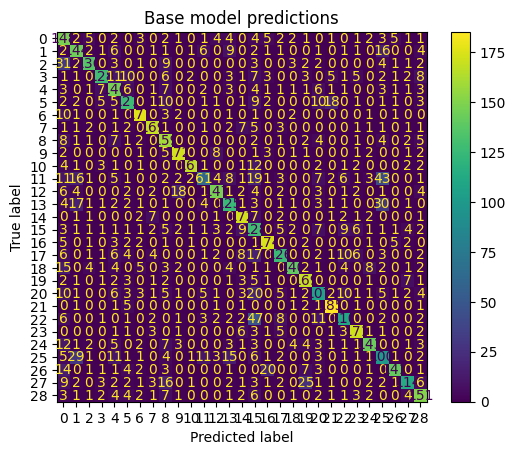

In [ ]:
# Visualize class predictions
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay

model_name = "multiple_lyers_model"

true_labels = np.concatenate([y for x, y in val_ds])
model_predictions = np.argmax(predictions, axis=1)

plt.figure(figsize=(16, 14))
ConfusionMatrixDisplay.from_predictions(true_labels, model_predictions)
plt.title("Base model predictions")
plt.savefig(f"model_performance/{model_name}/confusion_matrix.png")
plt.show()

In [ ]:
# Calculating and saving the metrics
import json

recall = recall_score(true_labels, model_predictions, average='macro')
precision = precision_score(true_labels, model_predictions, average='macro')
accuracy = accuracy_score(true_labels, model_predictions)
print(f"Recall: {recall:.2f}")
print(f"Precision: {precision:.2f}")
model_perf_dict = {"recall": recall, "precision": precision, "accuracy": accuracy}

with open("model_performance/base_model_101_classes/model_perf.json", "w") as f:
    json.dump(model_perf_dict, f)


Recall: 0.71
Precision: 0.73


In [ ]:
print(type(true_labels))

<class 'numpy.ndarray'>


In [ ]:
from evaluation_functions import create_model_summary_pdf

create_model_summary_pdf(true_labels, model_predictions)

NameError: name 'PDFPages' is not defined

In [ ]:
image = np.array(Image.open("data/train/pizza/5764.jpg"))
model.predict(image)

ValueError: Input 0 of layer "functional_6" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(32, 512, 3)

In [16]:
# Save the model
model.save("models/base_model_29_classes.keras") 